# Introduction

In this notebook we simulate the planar three-body problem using RK45 and validate results via energy and momentum conservation. We then compare dynamics across different mass distributions and explore the Figure 8 scenario, the Lagrange equilateral case and a Sun-Earth-Jupiter setup.

# Physical Model

## Model Description
This model defines the physical system being simulated and formulate its dynamics as a system of ODEs that can be solved numerically.
We consider **three point masses** interacting through **Newtonian gravity**, with motion constrained to **two spatial dimensions**.

For each body $i \in \{1,2,3\}$:

- Position: $\mathbf{r}_i(t) = (x_i(t), y_i(t))$
- Velocity: $\mathbf{v}_i(t) = (v_{x,i}(t), v_{y,i}(t))$
- Mass: $m_i > 0$

We work in nondimensional units and set the gravitational constant to

$$
G = 1
$$

Define the relative displacement vector between bodies $i$ and $j$:

$$
\mathbf{r}_{ij} = \mathbf{r}_i - \mathbf{r}_j,
\qquad
\|\mathbf{r}_{ij}\| = \sqrt{(x_i - x_j)^2 + (y_i - y_j)^2}
$$


## Equations of Motion

The gravitational force on body $i$ due to body $j$ is given by
$$
\mathbf{F}_{i \leftarrow j}
= -G m_i m_j
\frac{\mathbf{r}_i - \mathbf{r}_j}
{\|\mathbf{r}_i - \mathbf{r}_j\|^3}
$$
Summing over the other two bodies yields the total force on body $i$:
$$
\mathbf{F}_i =
\sum_{\substack{j=1 \\ j \neq i}}^{3}
\mathbf{F}_{i \leftarrow j}
$$
Using Newton’s second law $\mathbf{F}_i = m_i \mathbf{a}_i$, the acceleration is
$$
\ddot{\mathbf{r}}_i
= -G
\sum_{\substack{j=1 \\ j \neq i}}^{3}
m_j
\frac{\mathbf{r}_i - \mathbf{r}_j}
{\|\mathbf{r}_i - \mathbf{r}_j\|^3}
$$
With $G = 1$, this becomes
$$
\ddot{\mathbf{r}}_i
=
-
\sum_{\substack{j=1 \\ j \neq i}}^{3}
m_j
\frac{\mathbf{r}_i - \mathbf{r}_j}
{\|\mathbf{r}_i - \mathbf{r}_j\|^3}
$$

## ODE Formulation

To apply numerical methods, we write the system as a first-order ODE by introducing velocities as independent variables:

$$
\dot{\mathbf{r}}_i = \mathbf{v}_i,
\qquad
\dot{\mathbf{v}}_i = \ddot{\mathbf{r}}_i
$$

In component form:

$$
\dot{x}_i = v_{x,i},
\qquad
\dot{y}_i = v_{y,i}
$$

$$
\dot{v}_{x,i}
=
-
\sum_{\substack{j=1 \\ j \neq i}}^{3}
m_j
\frac{x_i - x_j}
{\left[(x_i - x_j)^2 + (y_i - y_j)^2\right]^{3/2}}
$$

$$
\dot{v}_{y,i}
=
-
\sum_{\substack{j=1 \\ j \neq i}}^{3}
m_j
\frac{y_i - y_j}
{\left[(x_i - x_j)^2 + (y_i - y_j)^2\right]^{3/2}}
$$

The full state vector is

$$
\mathbf{y}(t)
=
(x_1, y_1, x_2, y_2, x_3, y_3,
v_{x,1}, v_{y,1}, v_{x,2}, v_{y,2}, v_{x,3}, v_{y,3})^\top
\in \mathbb{R}^{12}
$$

Thus, the system can be written compactly as

$$
\dot{\mathbf{y}}(t) = f(\mathbf{y}(t))
$$

where the first 6 components are the velocity components and the last 6 components are accelerations.

This general three-body problem is not integrable (but the two-body problem admits closed-form analytical soltuions). The nonlinear gravitational interactions lead to **chaotic behavior**, where small changes in initial conditions can produce dramatically different trajectories. We will explore this behavior. This sensitivity to initial conditions makes numerical integration essential for studying the system.

# Numerical Method

## ODE integration approach
We chose to use RK45 because the three-body problem is a nonlinear, non-stiff system and the dynamics alternate between slow evolution and fast, sudden changes. RK45 is an explicit Runge-Kutta method that combines fourth- and fifth-order solutions to estimate the local truncation error and automatically adjust the timestep. This allows accurate and efficient integration and outperforms fixed-step methods such as RK4. Implicit solvers are unnecessary for this problem and while symplectic methods may provide better long-term energy conservation, their fixed step size makes them less suitable for the time scales considered.

We integrate the system forward in time using **`scipy.integrate.solve_ivp` with RK45**.
RK45 automatically adjusts the timestep to control local truncation error using absolute and relative tolerances:
- Relative tolerance: $\texttt{rtol}$
- Absolute tolerance: $\texttt{atol}$


Smaller tolerances typically improve conservation of energy and momentum at the cost of more function evaluations.
The simulation is run over a time interval
$$
t \in [t_0, t_f],
$$
chosen long enough to observe interesting dynamics (like close approaches and exchanges).

#### Softening for close encounters
Close encounters can produce extremely large accelerations because the Newtonian force scales like $1/r^2$, which can force very small timesteps or lead to numerical instability.

That's why we turn to the stabilization technique of **gravitational softening**, replacing $r^3$ in the denominator with a softened form:
$$
\frac{\mathbf{r}_{ij}}{\|\mathbf{r}_{ij}\|^3}
\;\;\longrightarrow\;\;
\frac{\mathbf{r}_{ij}}{\left(\|\mathbf{r}_{ij}\|^2+\varepsilon^2\right)^{3/2}},
$$
where $\varepsilon \ll 1$ is a small softening parameter.  
This prevents singular forces when $\|\mathbf{r}_{ij}\| \to 0$ while still approximating Newtonian gravity when separations are not extremely small.

To validate correctness and numerical stability, we shoud monitor the conserved quantities: in our case total momentum and energy.



## Conserved quantities

### Total momentum
The total linear momentum should remain approximately constant:
$$
\mathbf{P}(t)=\sum_{i=1}^{3} m_i \mathbf{v}_i(t).
$$


### Total energy
The total mechanical energy (kinetic + potential) should also remain approximately constant:
$$
E(t)=K(t)+U(t),
$$
where the kinetic energy is
$$
K(t)=\frac{1}{2}\sum_{i=1}^{3} m_i \|\mathbf{v}_i(t)\|^2,
$$
and the gravitational potential energy is
$$
U(t)= -G \sum_{1\le i<j\le 3} \frac{m_i m_j}{\|\mathbf{r}_i(t)-\mathbf{r}_j(t)\|}.
$$
With $G=1$:
$$
U(t)= - \sum_{1\le i<j\le 3} \frac{m_i m_j}{\|\mathbf{r}_i(t)-\mathbf{r}_j(t)\|}.
$$

If softening is used, the potential is
$$
U_\varepsilon(t)= - \sum_{1\le i<j\le 3} \frac{m_i m_j}{\sqrt{\|\mathbf{r}_i(t)-\mathbf{r}_j(t)\|^2+\varepsilon^2}}.
$$

# Initial Exploration

## Setting Up the System

In [ ]:
import numpy as np
from scipy.integrate import solve_ivp
import matplotlib.pyplot as plt
import pandas as pd

The system is set up following the formulas discussed above.

In [ ]:
# parameters

G = 1.0                       # gravitational constant
m = np.array([1.0, 1.0, 1.0]) # masses
eps = 1e-3                 # softening parameter (set to 0.0 to disable)

t0 = 0.0
tf = 50.0
num_points = 5000
t_eval = np.linspace(t0, tf, num_points)

In [ ]:
# ODE systerm

def three_body_ode(t, y, m, eps):
    # Unpack positions
    x1, y1, x2, y2, x3, y3 = y[:6]
    # Unpack velocities
    vx1, vy1, vx2, vy2, vx3, vy3 = y[6:]

    r1 = np.array([x1, y1])
    r2 = np.array([x2, y2])
    r3 = np.array([x3, y3])

    def accel(ri, rj, mj):
        rij = ri - rj
        dist2 = np.dot(rij, rij) + eps**2
        return -mj * rij / dist2**(3/2)

    a1 = accel(r1, r2, m[1]) + accel(r1, r3, m[2])
    a2 = accel(r2, r1, m[0]) + accel(r2, r3, m[2])
    a3 = accel(r3, r1, m[0]) + accel(r3, r2, m[1])

    dydt = np.zeros_like(y)
    dydt[:6] = [vx1, vy1, vx2, vy2, vx3, vy3] #dr/dt = v
    dydt[6:] = [a1[0], a1[1], a2[0], a2[1], a3[0], a3[1]] #dv/dt = a

    return dydt

In [ ]:
# initial conditions
# approximately symmetric initial conditions with zero total momentum to avoid COM drift

y0 = np.array([
    -1.0,  0.0,   # x1, y1
     1.0,  0.0,   # x2, y2
     0.0,  0.5,   # x3, y3
     0.0,  0.3,   # vx1, vy1
     0.0, -0.3,   # vx2, vy2
     0.0,  0.0    # vx3, vy3
])

In [ ]:
# numerical integration (RK45)

solution = solve_ivp(
    three_body_ode,
    (t0, tf),
    y0,
    args=(m, eps),
    method="RK45",
    t_eval=t_eval,
    rtol=1e-10,
    atol=1e-12
)

Y = solution.y

## Energy and Momentum

In [ ]:
# energy and momentum diagnostics

def total_energy(Y, m, eps):
    x1, y1, x2, y2, x3, y3 = Y[:6]
    vx1, vy1, vx2, vy2, vx3, vy3 = Y[6:]

    # kinetic energy
    K = (
        0.5 * m[0] * (vx1**2 + vy1**2)
        + 0.5 * m[1] * (vx2**2 + vy2**2)
        + 0.5 * m[2] * (vx3**2 + vy3**2)
    )

    def potential(ri, rj, mi, mj):
        dist = np.sqrt(np.sum((ri - rj)**2, axis=0) + eps**2)
        return -mi * mj / dist

    r1 = np.vstack((x1, y1))
    r2 = np.vstack((x2, y2))
    r3 = np.vstack((x3, y3))

    # potential energy
    U = (
        potential(r1, r2, m[0], m[1])
        + potential(r1, r3, m[0], m[2])
        + potential(r2, r3, m[1], m[2])
    )

    return K + U


def total_momentum(Y, m):
    vx1, vy1, vx2, vy2, vx3, vy3 = Y[6:]
    Px = m[0]*vx1 + m[1]*vx2 + m[2]*vx3
    Py = m[0]*vy1 + m[1]*vy2 + m[2]*vy3
    return Px, Py


# Compute diagnostics
E = total_energy(Y, m, eps)
Px, Py = total_momentum(Y, m)

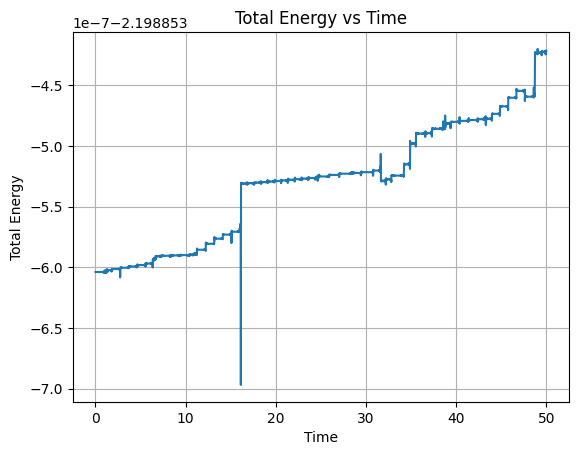

In [ ]:
# Energy vs Time

plt.figure()
plt.plot(solution.t, E)
plt.xlabel("Time")
plt.ylabel("Total Energy")
plt.title("Total Energy vs Time")
plt.grid(True)
plt.show()

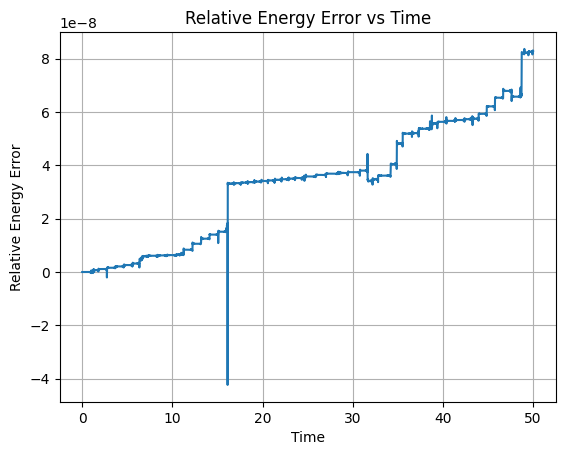

In [ ]:
E0 = E[0]
rel_energy_error = (E - E0) / abs(E0)
plt.figure()
plt.plot(solution.t, rel_energy_error)
plt.xlabel("Time")
plt.ylabel("Relative Energy Error")
plt.title("Relative Energy Error vs Time")
plt.grid(True)
plt.show()


From this initial run we can note that he total energy exhibits small fluctuations and mild drift over time. This behavior is expected when using an adaptive non-symplectic integrator such as RK45, particularly during close encounters. Energy is conserved to within $\sim 10^{-8}$ relative error over the simulated time interval, with small discontinuities associated with close encounters, indicating that the numerical integration is stable over the simulated time interval. This confirms that RK45 achieves sufficient accuracy for this study. More detailed analysis will follow later.

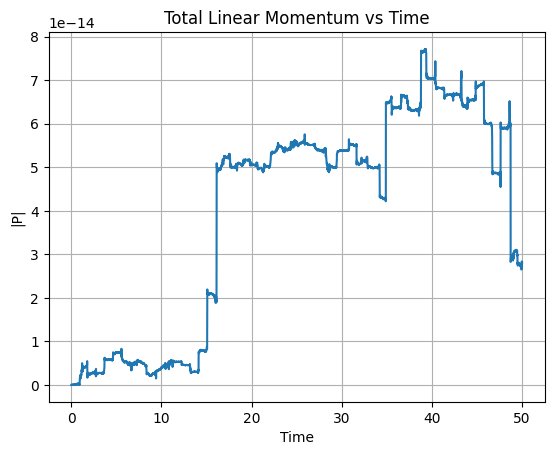

In [ ]:
#momentum plot
Px, Py = total_momentum(Y, m)
P_mag = np.sqrt(Px**2 + Py**2)
plt.figure()
plt.plot(solution.t, P_mag)
plt.xlabel("Time")
plt.ylabel("|P|")
plt.title("Total Linear Momentum vs Time")
plt.grid(True)
plt.show()

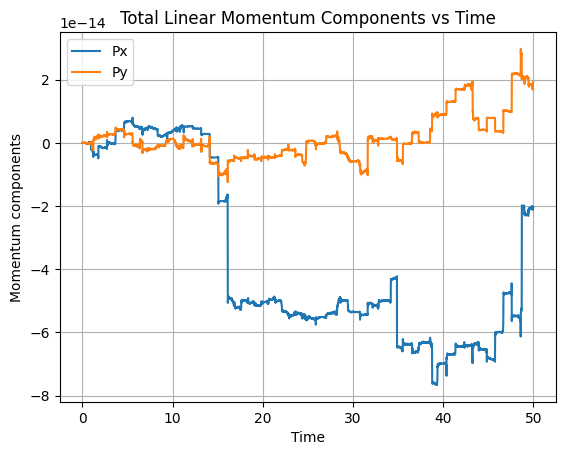

In [ ]:
plt.figure()
plt.plot(solution.t, Px, label="Px")
plt.plot(solution.t, Py, label="Py")
plt.xlabel("Time")
plt.ylabel("Momentum components")
plt.title("Total Linear Momentum Components vs Time")
plt.legend()
plt.grid(True)
plt.show()

The total linear momentum remains conserved to within
$\sim 10^{-14}$throughout the simulation and the momentum components
Px(t) and
Py(t) remain near zero at the
$\sim 10^{-14}$ level, confirming that the simulation is effectively in the center of mass frame and that internal forces are implemented consistently.

## Initial plots

Now we will plot soltuions to get an initial feel and visualise the behaviour of the three bodies with the same masses, with one light body and with one heavy body.

In [ ]:
def run_and_plot(masses):
    sol = solve_ivp(
        three_body_ode,
        (t0, tf),
        y0,
        args=(np.array(masses, dtype=float), eps),
        method="RK45",
        t_eval=t_eval,
        rtol=1e-9,
        atol=1e-9
    )

    Y = sol.y
    x1, y1, x2, y2, x3, y3 = Y[0], Y[1], Y[2], Y[3], Y[4], Y[5]

    plt.figure()
    plt.plot(x1, y1, label="Body 1")
    plt.plot(x2, y2, label="Body 2")
    plt.plot(x3, y3, label="Body 3")

    # mark starting positions
    plt.scatter([x1[0], x2[0], x3[0]], [y1[0], y2[0], y3[0]], marker="o")

    plt.xlabel("x")
    plt.ylabel("y")
    plt.title(f"Trajectories for masses {tuple(masses)}")
    plt.axis("equal")
    plt.grid(True)
    plt.legend()
    plt.show()

    return sol

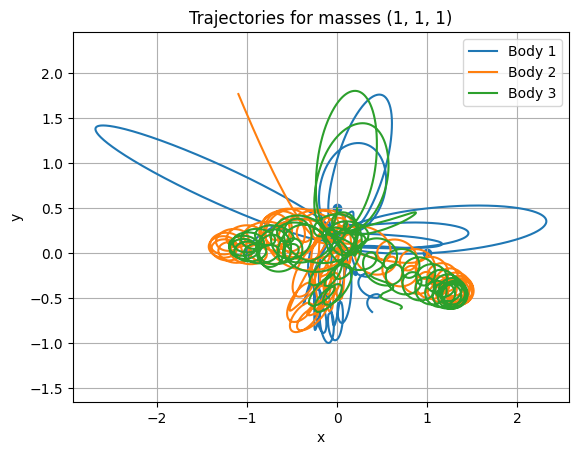

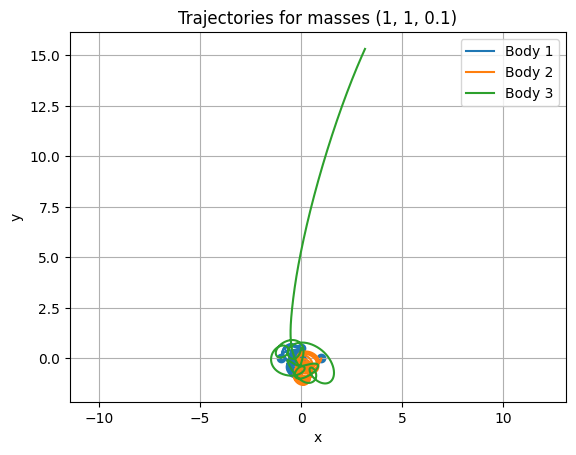

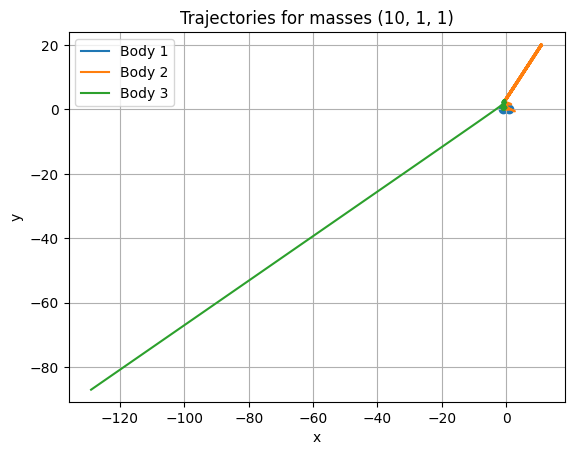

In [ ]:
# equal masses
sol_equal = run_and_plot((1, 1, 1))

# one light body
sol_light = run_and_plot((1, 1, 0.1))

# one heavy body
sol_heavy = run_and_plot((10, 1, 1))

From our initial setups we can notice that the dynamics depend strongly on the mass distribution. For equal masses all bodies interact comparably, leading to chaotic, intertwined trajectories with frequent close encounters. When one body is much lighter, the two heavier bodies tend to remain bound while the light body is ejected. With one dominant mass the motion becomes more hierarchical: the massive body anchors the system and one lighter body is scattered far away, while the other remains nearby.

## PyGame Animations

Now we can observe the dynamics from the solution even further using PyGame library.

In [ ]:
import pygame

pygame 2.6.1 (SDL 2.28.4, Python 3.12.12)
Hello from the pygame community. https://www.pygame.org/contribute.html


In [ ]:
def play_solution_pygame(sol, masses, width=900, height=700, fps=60, trail_len=120, scale=120, center=None):
    """
    sol.t : (N,)
    sol.y : (12, N) with positions in rows 0..5
    masses: (3,) for drawing radius (bigger mass = bigger circle)

    scale: converts simulation units to pixels
    center: pixel center of screen (defaults to middle)
    """
    pygame.init()
    screen = pygame.display.set_mode((width, height))
    clock = pygame.time.Clock()

    if center is None:
        center = (width // 2, height // 2)

    m = np.asarray(masses, dtype=float)

    # extract positions from solution
    x1, y1, x2, y2, x3, y3 = sol.y[0], sol.y[1], sol.y[2], sol.y[3], sol.y[4], sol.y[5]
    X = np.vstack([x1, x2, x3]).T  # (N,3)
    Y = np.vstack([y1, y2, y3]).T  # (N,3)
    N = X.shape[0]

    # colors
    colors = [(116, 148, 196), (106, 77, 97), (195, 212, 7)]

    # radii scale with sqrt(mass)
    radii = (np.sqrt(m) * 6).astype(int)
    radii = np.clip(radii, 4, 30)

    # trails store last positions in screen coords
    trails = [[], [], []]

    # helper: sim coords -> screen coords
    def to_screen(x, y):
        sx = int(center[0] + scale * x)
        sy = int(center[1] - scale * y)  # minus because pygame y increases downward
        return sx, sy

    i = 0
    running = True
    while running:
        clock.tick(fps)

        for event in pygame.event.get():
            if event.type == pygame.QUIT:
                running = False

        screen.fill((0, 0, 0))

        # update each body
        for k in range(3):
            sx, sy = to_screen(X[i, k], Y[i, k])
            trails[k].append((sx, sy))
            if len(trails[k]) > trail_len:
                trails[k].pop(0)

            # trail
            for p in trails[k]:
                pygame.draw.circle(screen, colors[k], p, 1)

            # body
            pygame.draw.circle(screen, colors[k], (sx, sy), int(radii[k]))

        # time label
        font = pygame.font.SysFont(None, 26)
        txt = font.render(f"t = {sol.t[i]:.2f}", True, (230, 230, 230))
        screen.blit(txt, (10, 10))

        pygame.display.flip()

        i += 1
        if i >= N:
            i = 0

    pygame.quit()

In [ ]:
# equal masses animation
play_solution_pygame(sol_equal, masses=(1,1,1))

KeyboardInterrupt: 

In [ ]:
# one light body animation
play_solution_pygame(sol_light, masses=(1,1,0.1))


In [ ]:
# one heavy body animation
play_solution_pygame(sol_heavy, masses=(10,1,1))

# Different Scenarios - Experiments and Analysis

In [ ]:
# Experiments Configuration
# Mass ratio: m = (1, 1, μ)
mu_grid = np.logspace(-1, 1, 25)   # 0.1 ... 10 (log-spaced)
mu_selected = [0.1, 1.0, 10.0]

# Use the same initial conditions as above (y0) and the same softening eps and G=1.
t0_scan = 0.0
tf_scan = 60.0
n_scan = 6000
t_eval_scan = np.linspace(t0_scan, tf_scan, n_scan)

# Escape radius in the center-of-mass frame
R_escape = 8.0

## Escape time

**Escape time** is defined as the first time \(t\) when the system looks “unbound” according to a simple geometric criterion.

1. Work in the **center-of-mass (COM) frame** (so overall drift does not look like “escape”).

2. Track distances of each body from the COM:
$$
r_i(t) = \left\|\mathbf{x}_i(t) - \mathbf{x}_{\rm COM}(t)\right\|.
$$

3. Declare **escape** at the **first time** any body satisfies **both**:
- it is far enough:
$$
r_i(t) > R_{\rm esc},
$$
- and it is moving outward:
$$
\frac{d}{dt} r_i(t) > 0,
$$
implemented via the dot-product test
$$
\left(\mathbf{x}_i - \mathbf{x}_{\rm COM}\right)\cdot\left(\mathbf{v}_i - \mathbf{v}_{\rm COM}\right) > 0.
$$

Then the **escape time** is that first \(t\).

If this never happens before the final integration time $t_f$, we label the run **bounded** and set the escape time to $t_f$.


In [ ]:

def unpack_state(Y):
    #Convert solver output Y (12,N) into positions/velocities arrays:
    #r: (N,3,2), v: (N,3,2)

    x1, y1, x2, y2, x3, y3 = Y[0], Y[1], Y[2], Y[3], Y[4], Y[5]
    vx1, vy1, vx2, vy2, vx3, vy3 = Y[6], Y[7], Y[8], Y[9], Y[10], Y[11]
    r = np.stack(
        [np.stack([x1, y1], axis=1),
         np.stack([x2, y2], axis=1),
         np.stack([x3, y3], axis=1)], axis=1
    )  # (N,3,2)
    v = np.stack(
        [np.stack([vx1, vy1], axis=1),
         np.stack([vx2, vy2], axis=1),
         np.stack([vx3, vy3], axis=1)], axis=1
    )  # (N,3,2)
    return r, v


def pairwise_distances(r):
    #r: (N,3,2) -> d12,d13,d23 each (N,)
    d12 = np.linalg.norm(r[:, 0, :] - r[:, 1, :], axis=1)
    d13 = np.linalg.norm(r[:, 0, :] - r[:, 2, :], axis=1)
    d23 = np.linalg.norm(r[:, 1, :] - r[:, 2, :], axis=1)
    return d12, d13, d23


def escape_metrics(sol, m, R_escape=8.0):
    """
    Distance-based escape indicator in the COM frame.
    - Escape if any body ends beyond R_escape from the COM.
    - Escape time: first time any body crosses R_escape with outward radial velocity (COM frame).
    """
    t = sol.t
    r, v = unpack_state(sol.y)

    M = np.sum(m)
    Rcm = (m[None, :, None] * r).sum(axis=1) / M            # (N,2)
    Vcm = (m[None, :, None] * v).sum(axis=1) / M            # (N,2)

    r_rel = r - Rcm[:, None, :]
    v_rel = v - Vcm[:, None, :]

    dist = np.linalg.norm(r_rel, axis=2)                    # (N,3)
    # radial speed > 0 means moving outward from the COM
    radial_speed = (r_rel * v_rel).sum(axis=2) / np.maximum(dist, 1e-12)

    # Escape if any body is far at final time
    escaped = bool(np.any(dist[-1, :] > R_escape))

    t_escape = np.nan
    escaping_body = None
    if escaped:
        # earliest crossing with outward motion, for any body
        candidates = np.where((dist > R_escape) & (radial_speed > 0.0))
        if len(candidates[0]) > 0:
            k = np.argmin(t[candidates[0]])
            idx = candidates[0][k]
            b = candidates[1][k]
            t_escape = t[idx]
            escaping_body = int(b) + 1

    return escaped, t_escape, escaping_body


def energy_drift(Y, m, eps):
    E = total_energy(Y, m, eps)
    E0 = E[0]
    drift = np.max(np.abs(E - E0)) / np.maximum(np.abs(E0), 1e-300)
    return drift


In [ ]:

def simulate_for_mu(mu, y0=y0, eps=eps, rtol=1e-7, atol=1e-10):
    m = np.array([1.0, 1.0, float(mu)])
    sol = solve_ivp(
        three_body_ode,
        (t0_scan, tf_scan),
        y0,
        args=(m, eps),
        method="RK45",
        t_eval=t_eval_scan,
        rtol=rtol,
        atol=atol
    )
    if sol.status < 0:
        return sol, {
            "mu": float(mu),
            "escaped": np.nan,
            "t_escape": np.nan,
            "escaping_body": np.nan,
            "min_sep": np.nan,
            "rel_energy_drift": np.nan,
            "success": False,
            "message": sol.message,
        }

    r, _ = unpack_state(sol.y)
    d12, d13, d23 = pairwise_distances(r)
    min_sep = float(np.min(np.minimum(np.minimum(d12, d13), d23)))

    escaped, t_esc, esc_body = escape_metrics(sol, m, R_escape=R_escape)
    drift = float(energy_drift(sol.y, m, eps))

    return sol, {
        "mu": float(mu),
        "escaped": bool(escaped),
        "t_escape": float(t_esc) if np.isfinite(t_esc) else np.nan,
        "escaping_body": esc_body if esc_body is not None else np.nan,
        "min_sep": min_sep,
        "rel_energy_drift": drift,
        "success": True,
        "message": sol.message,
    }


# Run the μ-sweep (store solutions only for selected μ)
results = []
solutions_selected = {}

for mu_ in mu_grid:
    sol, row = simulate_for_mu(mu_)
    results.append(row)
    if any(np.isclose(mu_, ms, rtol=0, atol=1e-12) for ms in mu_selected):
        solutions_selected[float(mu_)] = sol

df_mu = pd.DataFrame(results).sort_values("mu").reset_index(drop=True)
df_mu


,mu,escaped,t_escape,escaping_body,min_sep,rel_energy_drift,success,message
0,0.100000,True,26.424404,3.0,0.028390,0.000019,True,The solver successfully reached the end of the...
1,0.121153,False,NaN,NaN,0.033044,0.000029,True,The solver successfully reached the end of the...
2,0.146780,True,11.761960,3.0,0.025957,0.000020,True,The solver successfully reached the end of the...
3,0.177828,False,NaN,NaN,0.009396,0.000018,True,The solver successfully reached the end of the...
4,0.215443,False,NaN,NaN,0.003095,0.000122,True,The solver successfully reached the end of the...
5,0.261016,True,45.727621,3.0,0.004464,0.000284,True,The solver successfully reached the end of the...
6,0.316228,True,35.415903,3.0,0.018044,0.000059,True,The solver successfully reached the end of the...
7,0.383119,False,NaN,NaN,0.008835,0.000119,True,The solver successfully reached the end of the...
8,0.464159,False,NaN,NaN,0.014560,0.000162,True,The solver successfully reached the end of the...
9,0.562341,False,NaN,NaN,0.005079,0.000172,True,The solver successfully reached the end of the...


In [ ]:
mu = df_mu["mu"].to_numpy()
escaped = df_mu["escaped"].fillna(False).astype(bool).to_numpy()
t_escape = df_mu["t_escape"].to_numpy()
min_sep = df_mu["min_sep"].to_numpy()
drift = df_mu["rel_energy_drift"].to_numpy()

# For plotting "escape time" with bounded runs: show as tf_scan (censored)
t_escape_plot = np.where(np.isfinite(t_escape), t_escape, tf_scan)

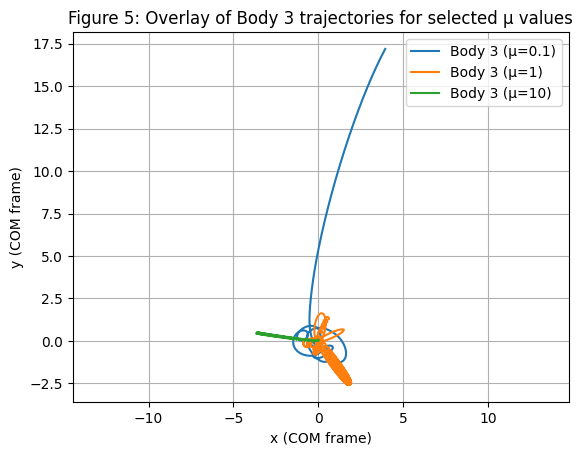

In [ ]:
# We overlay the trajectory of the μ-body (Body 3) for μ ∈ {0.1, 1, 10} in the COM frame.
plt.figure()

for mu0 in mu_selected:
    # Re-simulate if not already cached (in case of floating-point mismatch)
    sol = solutions_selected.get(float(mu0))
    if sol is None:
        sol, _ = simulate_for_mu(mu0)

    m = np.array([1.0, 1.0, float(mu0)])
    r, v = unpack_state(sol.y)
    M = m.sum()
    Rcm = (m[None, :, None] * r).sum(axis=1) / M
    r_rel = r - Rcm[:, None, :]

    x3, y3 = r_rel[:, 2, 0], r_rel[:, 2, 1]
    plt.plot(x3, y3, label=f"Body 3 (μ={mu0:g})")

plt.xlabel("x (COM frame)")
plt.ylabel("y (COM frame)")
plt.title("Overlay of Body 3 trajectories for selected μ values")
plt.axis("equal")
plt.grid(True)
plt.legend()
plt.show()

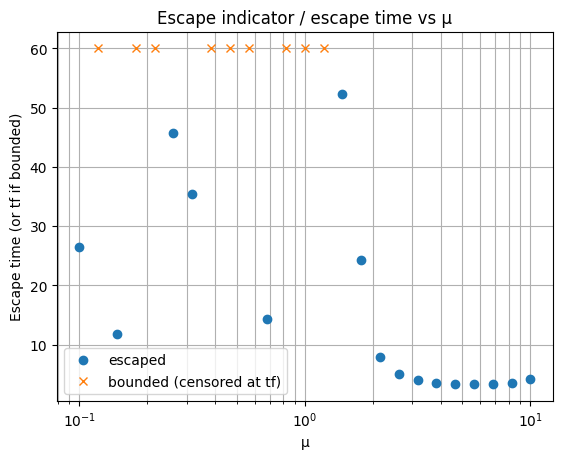

In [ ]:
# Escape time vs μ (bounded runs are shown at t=tf_scan)
plt.figure()

plt.semilogx(mu[escaped], t_escape_plot[escaped], marker="o", linestyle="", label="escaped")
plt.semilogx(mu[~escaped], t_escape_plot[~escaped], marker="x", linestyle="", label="bounded (censored at tf)")

plt.xlabel("μ")
plt.ylabel("Escape time (or tf if bounded)")
plt.title("Escape indicator / escape time vs μ")
plt.grid(True, which="both")
plt.legend()
plt.show()

- For our chosen initial conditions, for large μ, escape is fast and persistent. The blue points collapse to very small escape times (~3–6) and stay there up to μ=10. That’s a strong signal that once the third mass becomes sufficiently dominant, the dynamics almost always lead to an ejection quickly (often via a close encounter / slingshot).

- Given our specific initial conditions, around μ = 1, the graph suggests longer-lived, more stable-looking configurations for these mass ratios.

## Minimum separation (minimum pairwise distance)

Minimum separation is a “how close did they get?” measure.

#### Definition
For each pair of bodies $(i,j)$, compute the distance over time:
$$
d_{ij}(t) = \left\|\mathbf{x}_i(t) - \mathbf{x}_j(t)\right\|.
$$

At each time, take the closest pair:
$$
d_{\min}(t) = \min_{i<j} d_{ij}(t).
$$

Then the minimum separation for the whole run is:
$$
d_{\min} = \min_{t\in[0,t_f]} d_{\min}(t)
= \min_{t\in[0,t_f]}\ \min_{i<j}\left\|\mathbf{x}_i(t) - \mathbf{x}_j(t)\right\|.
$$


In [ ]:
# Minimum separation vs μ
plt.figure()
plt.loglog(mu, min_sep, marker="o", linestyle="")
plt.xlabel("μ")
plt.ylabel("Minimum pairwise separation")
plt.title("Minimum separation vs μ")
plt.grid(True, which="both")
plt.show()

NameError: name 'mu' is not defined

<Figure size 640x480 with 0 Axes>

- Large scatter at all μ: the wide spread in minimum separation reflects the chaotic sensitivity of the three-body problem; with random initial conditions, small changes in μ can lead to very different closest-approach geometries.

- Smaller separations at larger μ: for higher mass ratios, the system more often experiences very close encounters, consistent with stronger gravitational focusing and the onset of rapid ejection events.

## Relative energy drift (numerical accuracy)

**Relative energy drift** measures how well the numerical integrator conserves the system’s total mechanical energy.  
In the exact (continuous) Newtonian 3-body problem, the total energy should be constant, so any change you see is due to numerical error.

#### Definition
Define the **relative energy error** at time $t$ by
$$
\delta_E(t) = \frac{|E(t)-E(0)|}{|E(0)|}.
$$

The reported **relative energy drift** for a run is the maximum of this quantity over the integration window:
$$
\text{drift} = \max_{t\in[0,t_f]} \delta_E(t)
= \max_{t\in[0,t_f]} \frac{|E(t)-E(0)|}{|E(0)|}.
$$

#### Interpretation
- Smaller drift $\Rightarrow$ better numerical accuracy (energy is nearly conserved).
- Larger drift usually occurs during **close encounters**, when $\|\mathbf{x}_i-\mathbf{x}_j\|$ becomes small, accelerations grow like $\sim 1/r^2$, and the problem becomes harder to integrate accurately with fixed tolerances.


In [ ]:
# Relative energy drift vs μ
plt.figure()
plt.loglog(mu, drift, marker="o", linestyle="")
plt.xlabel("μ")
plt.ylabel("Max relative energy drift")
plt.title("Relative energy drift vs μ")
plt.grid(True, which="both")
plt.show()

# Notable instances

## Figure 8 Scenario

The **figure-eight** is a classic 2D three-body benchmark: three **equal masses** follow the same closed “8”-shaped curve, phase-shifted in time

- **Zero total linear momentum**
- **Zero total angular momentum**
- **Symmetric initial setup** (paired bodies and one at the origin) - the motion repeats periodically


In [ ]:
# Standard Chenciner–Montgomery figure-eight initial conditions (G=1, m1=m2=m3=1)
m_fig8 = np.array([1.0, 1.0, 1.0], dtype=float)

y0_fig8 = np.array([
    -0.97000436,  0.24308753,
     0.97000436, -0.24308753,
     0.0,         0.0,
     0.4662036850,  0.4323657300,
     0.4662036850,  0.4323657300,
    -0.9324073700, -0.8647314600
], dtype=float)

eps_fig8 = 0.0  # no softening (changes dynamics)

# One period is ~ 6.3259 (in these units)
t0_fig8 = 0.0
T_fig8  = 6.32591398
tf_fig8 = 3 * T_fig8
t_eval_fig8 = np.linspace(t0_fig8, tf_fig8, 60000)

sol_fig8 = solve_ivp(
    three_body_ode,
    (t0_fig8, tf_fig8),
    y0_fig8,
    args=(m_fig8, eps_fig8),
    method="RK45",
    t_eval=t_eval_fig8,
    rtol=1e-10,
    atol=1e-10
)

Y = sol_fig8.y
x1, y1, x2, y2, x3, y3 = Y[0], Y[1], Y[2], Y[3], Y[4], Y[5]

plt.figure()
plt.plot(x1, y1, label="Body 1")
plt.plot(x2, y2, label="Body 2")
plt.plot(x3, y3, label="Body 3")

# mark starting positions
plt.scatter([x1[0], x2[0], x3[0]], [y1[0], y2[0], y3[0]], marker="o")

plt.xlabel("x")
plt.ylabel("y")
plt.title("Figure X: Figure-eight periodic orbit (m1=m2=m3=1)")
plt.axis("equal")
plt.grid(True)
plt.legend()
plt.show()

print("Energy drift (max relative):", energy_drift(sol_fig8.y, m_fig8, eps_fig8))


NameError: name 'np' is not defined

In [ ]:
# pygame animation for the Figure 8 simulation - using sol_fig8 function
Y = sol_fig8.y
t = sol_fig8.t

x1, y1, x2, y2, x3, y3 = Y[0], Y[1], Y[2], Y[3], Y[4], Y[5]
vx1, vy1, vx2, vy2, vx3, vy3 = Y[6], Y[7], Y[8], Y[9], Y[10], Y[11]

def offset_along_normal(x, y, vx, vy, delta):
    speed = np.hypot(vx, vy)
    speed = np.where(speed == 0, 1.0, speed)
    nx = -vy / speed
    ny =  vx / speed
    return x + delta * nx, y + delta * ny

# Visualization-only offsets so trails don’t perfectly overlap
deltas = [-0.01, 0.0, 0.01]
x1v, y1v = offset_along_normal(x1, y1, vx1, vy1, deltas[0])
x2v, y2v = offset_along_normal(x2, y2, vx2, vy2, deltas[1])
x3v, y3v = offset_along_normal(x3, y3, vx3, vy3, deltas[2])

# Pack for easier looping
traj = [
    np.column_stack([x1v, y1v]),
    np.column_stack([x2v, y2v]),
    np.column_stack([x3v, y3v]),
]

# Pygame setup
pygame.init()
W, H = 900, 900
screen = pygame.display.set_mode((W, H))
pygame.display.set_caption("3-Body Figure-Eight (2D)")
clock = pygame.time.Clock()

# Compute world bounds
all_xy = np.vstack(traj)
xmin, ymin = all_xy.min(axis=0)
xmax, ymax = all_xy.max(axis=0)

# Add margin
mx = 0.15 * (xmax - xmin)
my = 0.15 * (ymax - ymin)
xmin -= mx; xmax += mx
ymin -= my; ymax += my

def world_to_screen(x, y):
    # keep aspect ratio
    sx = (x - xmin) / (xmax - xmin) * (W - 40) + 20
    sy = (y - ymin) / (ymax - ymin) * (H - 40) + 20
    # invert y for screen coordinates
    return int(sx), int(H - sy)

# Colors
colors = [(220, 60, 60), (60, 200, 80), (80, 120, 240)]
bg = (10, 10, 14)

# Trail settings
trail_len = 2000   # number of points to draw behind each body
point_radius = 6
fps = 60

step = max(1, len(t) // (fps * 20))

running = True
i = 0

while running:
    clock.tick(fps)

    for event in pygame.event.get():
        if event.type == pygame.QUIT:
            running = False
        elif event.type == pygame.KEYDOWN:
            if event.key == pygame.K_ESCAPE:
                running = False
            elif event.key == pygame.K_SPACE:
                # pause/unpause toggle
                paused = True
                while paused:
                    for e in pygame.event.get():
                        if e.type == pygame.QUIT:
                            paused = False
                            running = False
                        elif e.type == pygame.KEYDOWN and e.key == pygame.K_SPACE:
                            paused = False
                    clock.tick(30)

    screen.fill(bg)

    # Draw trails + current points
    for k in range(3):
        pts = traj[k]
        j0 = max(0, i - trail_len)
        trail_pts = pts[j0:i+1]

        # Draw trail as a polyline
        if len(trail_pts) >= 2:
            poly = [world_to_screen(px, py) for px, py in trail_pts]
            pygame.draw.lines(screen, colors[k], False, poly, 2)

        # Draw current position
        cx, cy = world_to_screen(pts[i, 0], pts[i, 1])
        pygame.draw.circle(screen, colors[k], (cx, cy), point_radius)

    pygame.display.flip()

    i += step
    if i >= len(t):
        i = 0  # loop animation

pygame.quit()


## Lagrange equilateral (rotating triangle) solution

In the **Lagrange equilateral** solution, three bodies form an **equilateral triangle** that **rigidly rotates** about the center of mass while keeping all pairwise distances **constant**. Each body moves on a circle, and the triangle’s shape is preserved for all time.

This is a classic symmetry/stability benchmark: if the integrator is accurate, the triangle should remain equilateral (up to small numerical error), with small energy drift and no spurious deformation.


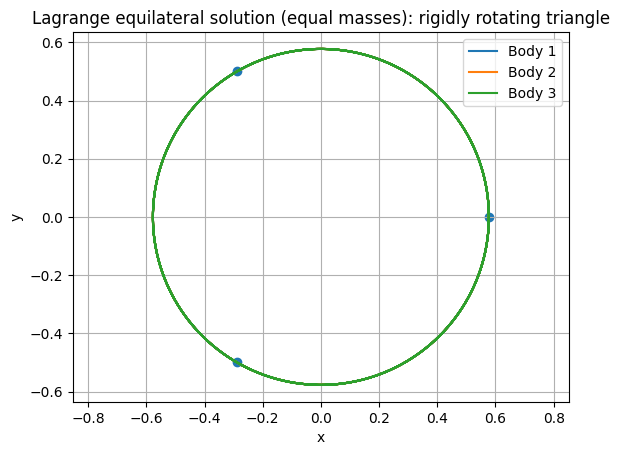

Energy drift (max relative): 4.187793815428147e-09


In [ ]:
# Lagrange equilateral rotating triangle (equal masses) — static 2D plot

m_lagr = np.array([1.0, 1.0, 1.0], dtype=float)
a = 1.0

# Distance from center-of-mass to each vertex for an equilateral triangle: R = a / sqrt(3)
R = a / np.sqrt(3)

# Angular speed for equal masses (G=1): omega^2 = 3*G*m / a^3  (here m=1)
omega = np.sqrt(3.0 / (a**3))

# Vertex positions (centered at origin)
r1 = np.array([ R, 0.0])
r2 = np.array([-R/2,  (np.sqrt(3)/2)*R])
r3 = np.array([-R/2, -(np.sqrt(3)/2)*R])

# Rigid rotation velocities: v = omega * z-hat x r = (-omega*y, omega*x)
v1 = np.array([-omega*r1[1], omega*r1[0]])
v2 = np.array([-omega*r2[1], omega*r2[0]])
v3 = np.array([-omega*r3[1], omega*r3[0]])

y0_lagr = np.array([
    r1[0], r1[1],
    r2[0], r2[1],
    r3[0], r3[1],
    v1[0], v1[1],
    v2[0], v2[1],
    v3[0], v3[1]
], dtype=float)

eps_lagr = 0.0
T_lagr = 2*np.pi / omega
t0_lagr = 0.0
tf_lagr = 5 * T_lagr
t_eval_lagr = np.linspace(t0_lagr, tf_lagr, 20000)

sol_lagr = solve_ivp(
    three_body_ode,
    (t0_lagr, tf_lagr),
    y0_lagr,
    args=(m_lagr, eps_lagr),
    method="RK45",
    t_eval=t_eval_lagr,
    rtol=1e-10,
    atol=1e-10
)

Y = sol_lagr.y
x1, y1, x2, y2, x3, y3 = Y[0], Y[1], Y[2], Y[3], Y[4], Y[5]

plt.figure()
plt.plot(x1, y1, label="Body 1")
plt.plot(x2, y2, label="Body 2")
plt.plot(x3, y3, label="Body 3")

plt.scatter([x1[0], x2[0], x3[0]], [y1[0], y2[0], y3[0]], marker="o")
plt.xlabel("x")
plt.ylabel("y")
plt.title("Lagrange equilateral solution (equal masses): rigidly rotating triangle")
plt.axis("equal")
plt.grid(True)
plt.legend()
plt.show()

print("Energy drift (max relative):", energy_drift(sol_lagr.y, m_lagr, eps_lagr))


In [ ]:
#pygame simulation
Y = sol_lagr.y
t = sol_lagr.t

x1, y1, x2, y2, x3, y3 = Y[0], Y[1], Y[2], Y[3], Y[4], Y[5]

traj = [
    np.column_stack([x1, y1]),
    np.column_stack([x2, y2]),
    np.column_stack([x3, y3]),
]

pygame.init()
W, H = 900, 900
screen = pygame.display.set_mode((W, H))
pygame.display.set_caption("3-Body Lagrange Equilateral Solution")
clock = pygame.time.Clock()

# World bounds
all_xy = np.vstack(traj)
xmin, ymin = all_xy.min(axis=0)
xmax, ymax = all_xy.max(axis=0)
mx = 0.25 * (xmax - xmin)
my = 0.25 * (ymax - ymin)
xmin -= mx; xmax += mx
ymin -= my; ymax += my

def world_to_screen(x, y):
    sx = (x - xmin) / (xmax - xmin) * (W - 40) + 20
    sy = (y - ymin) / (ymax - ymin) * (H - 40) + 20
    return int(sx), int(H - sy)

colors = [(220, 60, 60), (60, 200, 80), (80, 120, 240)]
bg = (10, 10, 14)

trail_len = 2500
point_radius = 7
fps = 60

# Playback speed (samples per frame)
step = max(1, len(t) // (fps * 20))

running = True
i = 0

while running:
    clock.tick(fps)

    for event in pygame.event.get():
        if event.type == pygame.QUIT:
            running = False
        elif event.type == pygame.KEYDOWN:
            if event.key == pygame.K_ESCAPE:
                running = False
            elif event.key == pygame.K_SPACE:
                paused = True
                while paused:
                    for e in pygame.event.get():
                        if e.type == pygame.QUIT:
                            paused = False
                            running = False
                        elif e.type == pygame.KEYDOWN and e.key == pygame.K_SPACE:
                            paused = False
                    clock.tick(30)

    screen.fill(bg)

    # Draw trails and current positions
    for k in range(3):
        pts = traj[k]
        j0 = max(0, i - trail_len)
        trail_pts = pts[j0:i+1]

        if len(trail_pts) >= 2:
            poly = [world_to_screen(px, py) for px, py in trail_pts]
            pygame.draw.lines(screen, colors[k], False, poly, 2)

        cx, cy = world_to_screen(pts[i, 0], pts[i, 1])
        pygame.draw.circle(screen, colors[k], (cx, cy), point_radius)

    pygame.display.flip()

    i += step
    if i >= len(t):
        i = 0

pygame.quit()


NameError: name 'pygame' is not defined

## Sun - Earth - Jupiter System


We initialize a simplified Sun–Earth–Jupiter three-body system using realistic mass ratios (in solar masses) and orbital radii (in Astronomical Units). The Sun is placed at the origin, Earth at
1 AU and Jupiter at 5.2 AU on opposite sides of the
x-axis. Initial velocities are chosen tangentially using two-body circular-orbit estimate and we subtract the center of mass velocity so the total momentum is zero and the COM remains fixed.

Note: These are not exact Solar System initial conditions: the phase and velocity directions are simplified (e.g. Jupiter is set moving opposite to Earth). Also, the “circular” speeds come from a two-body approximation, so once mutual interactions are included the trajectories will not remain perfectly circular.

In [ ]:
# Sun–Earth–Jupiter initial conditions (dimensionless)
def make_sun_earth_jupiter_y0(G=1.0):
    # masses in solar-mass units
    m_sun = 1.0
    m_earth = 3.003e-6
    m_jupiter = 9.545e-4

    # distances in Astronomical Units (AU)
    r_se = 1.0     # Earth
    r_sj = 5.2     # Jupiter

    # positions: Sun at origin, Earth on +x, Jupiter on -x
    r1 = np.array([0.0, 0.0])      # Sun
    r2 = np.array([r_se, 0.0])     # Earth
    r3 = np.array([-r_sj, 0.0])    # Jupiter

    # circular-ish speeds around the Sun (tangential)
    v_earth = np.sqrt(G * m_sun / r_se)
    v_jupiter = np.sqrt(G * m_sun / r_sj)

    v1 = np.array([0.0, 0.0])
    v2 = np.array([0.0,  v_earth])
    v3 = np.array([0.0, -v_jupiter])  # opposite direction for variety

    # COM velocity correction (keeps COM fixed)
    m = np.array([m_sun, m_earth, m_jupiter], dtype=float)
    P = m[0]*v1 + m[1]*v2 + m[2]*v3
    Vcm = P / m.sum()
    v1 -= Vcm; v2 -= Vcm; v3 -= Vcm

    y0 = np.array([
        r1[0], r1[1],
        r2[0], r2[1],
        r3[0], r3[1],
        v1[0], v1[1],
        v2[0], v2[1],
        v3[0], v3[1],
    ], dtype=float)

    return y0, m

In [ ]:
#build and solve
y0_sej, m_sej = make_sun_earth_jupiter_y0(G=G)
t0_sej, tf_sej = 0.0, 80.0
t_eval_sej = np.linspace(t0_sej, tf_sej, 40000)

sol_sej = solve_ivp(
    three_body_ode,
    (t0_sej, tf_sej),
    y0_sej,
    args=(m_sej, eps),
    method="RK45",
    t_eval=t_eval_sej,
    rtol=1e-9,
    atol=1e-9
)

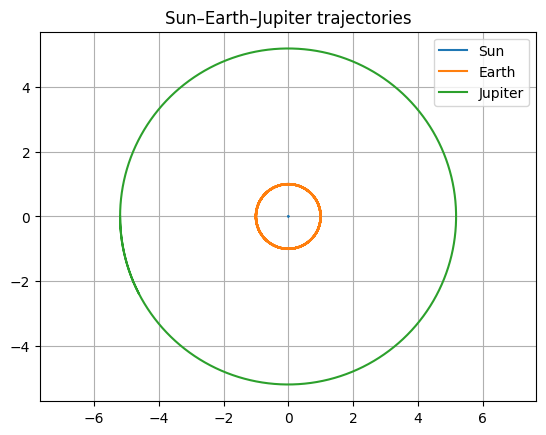

In [ ]:
# plot trajectories
Y = sol_sej.y
x1,y1,x2,y2,x3,y3 = Y[0],Y[1],Y[2],Y[3],Y[4],Y[5]

plt.figure()
plt.plot(x1, y1, label="Sun")
plt.plot(x2, y2, label="Earth")
plt.plot(x3, y3, label="Jupiter")
plt.axis("equal"); plt.grid(True); plt.legend()
plt.title("Sun–Earth–Jupiter trajectories")
plt.show()

We can notice that the system behaves hierarchically: the Sun dominates, so Earth and Jupiter follow nearly circular, Sun-centered orbits at roughly 1 AU and 5.2 AU.

Over the simulated time window, mutual perturbations are small, so the trajectories stay clean and close to the two-body “circular” initial design (no close encounters or ejections). The Sun remains near the origin (only a tiny wobble at most - look at animation), which is consistent with the center of mass momentum correction and the Sun’s much larger mass.

In [ ]:
# pygame simulation

play_solution_pygame(
    sol_sej,
    masses=m_sej,
    width=1400,
    height=900,
    fps=60,
    trail_len=300,
    scale=86,
    center=None
)

NameError: name 'play_solution_pygame' is not defined

# Final Comments

Our simulations reproduced the expected range of three-body behavior: starting from random initial conditions, the simulations quickly exhibited chaotic and unpredictable motion, underscoring the inherent sensitivity of the three-body problem.
In contrast, the Lagrange and figure-eight configurations remained stable over time, validating both the numerical implementation and known analytical solutions. Together, these cases highlight the sharp transition between chaotic behavior and highly structured motion in three-body dynamics. Overall, these results confirm that our numerical setup captures the key qualitative features of three-body dynamics across both chaotic and structured regimes.